# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** Saurav Shankar
**Register Number:** AP24110010128
**Date:** 22/08/2026

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [ ]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [ ]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [ ]:
tips_missing_tip = tips.copy()
np.random.seed(42)
missing_idx_tip = np.random.choice(tips_missing_tip.index, size=5, replace=False)
tips_missing_tip.loc[missing_idx_tip, 'tip'] = np.nan

print("Missing values:", tips_missing_tip['tip'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing_tip['tip'].isna().sum() / len(tips_missing_tip)))

# Fill using the median tip, grouped by time (Lunch/Dinner)
time_medians = tips_missing_tip.groupby('time')['tip'].transform('median')
tips_tip_filled = tips_missing_tip.copy()
tips_tip_filled['tip'] = tips_tip_filled['tip'].fillna(time_medians)

print("Remaining missing:", tips_tip_filled['tip'].isna().sum())
tips_tip_filled.loc[missing_idx_tip, ['time', 'tip']]


Missing values: 5
Percentage missing: 2.0%
Remaining missing: 0


,time,tip
24,Dinner,3.0
6,Dinner,3.0
153,Dinner,3.0
211,Dinner,3.0
198,Lunch,2.3


**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:*

Dinner tips tend to run higher than lunch tips because dinner bills are typically larger, so lumping both together into one global mean would pull lunch fills upward and dinner fills downward, distorting both groups. For example, if lunch tips average around \$2.50 and dinner tips average around \$3.50, filling a missing *lunch* tip with the overall mean (\$3.00) overestimates it, while filling a missing *dinner* tip with that same number underestimates it. Grouping by `time` (or `day`) keeps each fill consistent with the pattern that's actually present in that subgroup, which produces more realistic, less biased values.



## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [ ]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [ ]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


,day,day_Thur,day_Fri,day_Sat,day_Sun
0,Sun,False,False,False,True
1,Sun,False,False,False,True
2,Sun,False,False,False,True
3,Sun,False,False,False,True
4,Sun,False,False,False,True


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:*


In [ ]:
# Prediction: `time` only has 2 categories (Lunch, Dinner) and there's no inherent order
# between them. Because it's a *binary* category, label encoding (0/1) is a safe choice here --
# for a binary variable, label encoding and one-hot encoding are mathematically equivalent
# (one-hot would just create two perfectly complementary 0/1 columns), so the simpler
# label-encoded single column is preferred.

tips_enc['time_encoded'] = tips_enc['time'].map({'Lunch': 0, 'Dinner': 1})
tips_enc[['time', 'time_encoded']].head()


,time,time_encoded
0,Dinner,1
1,Dinner,1
2,Dinner,1
3,Dinner,1
4,Dinner,1


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*

Label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 introduces a fake numeric relationship that doesn't exist in the real world -- it implies Sun (3) is "three times" Thur (0), or that Fri is "between" Thur and Sat in some meaningful quantity. A model that uses distances or coefficients (like linear regression or KNN) will pick up on that ordering and could, for example, learn that spending increases steadily from Thur to Sun just because of the numbers assigned, not because of any real pattern in the data. One-hot encoding avoids this by giving each day its own independent 0/1 column, so no false ordering or magnitude is implied.



## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [ ]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [ ]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:*

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [ ]:
# Prediction: after standardizing, the mean of total_bill_standardized should be
# approximately 0, and the standard deviation should be approximately 1.

print("Mean:", tips_enc['total_bill_standardized'].mean())
print("Std:", tips_enc['total_bill_standardized'].std())

# Min-max scale the `size` column
tips_enc['size_scaled'] = min_max_scale(tips_enc['size'])
tips_enc[['size', 'size_scaled']].describe()


Mean: -6.028875031263658e-17
Std: 1.0


,size,size_scaled
count,244.000,244.000
mean,2.570,0.314
std,0.951,0.190
min,1.000,0.000
25%,2.000,0.200
50%,2.000,0.200
75%,3.000,0.400
max,6.000,1.000


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:*

Min-max scaling squeezes every value into a fixed [0, 1] range based on the column's min and max, while standardization re-centers the data around a mean of 0 with a standard deviation of 1, without bounding it to a fixed range. Min-max scaling is very sensitive to outliers -- a single extreme value stretches the min or max and compresses every other point into a tiny sliver of the range. Standardization is more robust to outliers because it uses the mean and standard deviation rather than the min/max, though extreme outliers can still pull the mean and inflate the standard deviation somewhat. In practice, standardization is often preferred when outliers are present or when an algorithm assumes roughly normal, zero-centered data (e.g. linear/logistic regression, PCA), while min-max scaling is useful when a bounded range is needed (e.g. neural network inputs, image pixels).



## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [ ]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


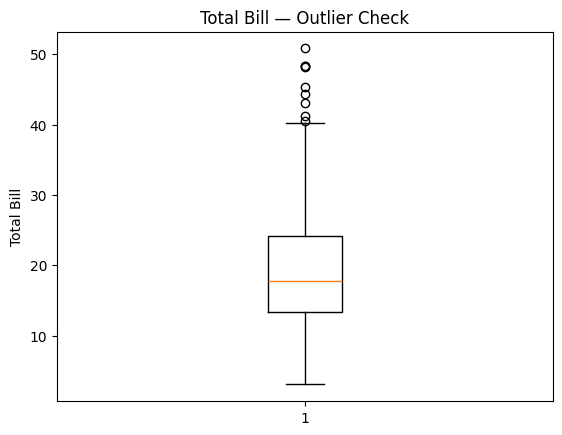

In [ ]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [ ]:
Q1_tip = tips['tip'].quantile(0.25)
Q3_tip = tips['tip'].quantile(0.75)
IQR_tip = Q3_tip - Q1_tip

lower_bound_tip = Q1_tip - 1.5 * IQR_tip
upper_bound_tip = Q3_tip + 1.5 * IQR_tip

outliers_tip = tips[(tips['tip'] < lower_bound_tip) | (tips['tip'] > upper_bound_tip)]
print(f"Bounds: [{lower_bound_tip:.2f}, {upper_bound_tip:.2f}]")
print(f"Number of outliers: {len(outliers_tip)}")
print(outliers_tip[['tip', 'day', 'size']])

# Cap (winsorize) outliers instead of dropping them
tips_capped = tips.copy()
tips_capped['tip'] = tips_capped['tip'].clip(lower=lower_bound_tip, upper=upper_bound_tip)

print("\nMax tip before capping:", tips['tip'].max())
print("Max tip after capping:  ", tips_capped['tip'].max())
print("Number of tip outliers remaining after cap:",
      ((tips_capped['tip'] < lower_bound_tip) | (tips_capped['tip'] > upper_bound_tip)).sum())


Bounds: [-0.34, 5.91]
Number of outliers: 9
       tip   day  size
23    7.58   Sat     4
47    6.00   Sun     4
59    6.73   Sat     4
141   6.70  Thur     6
170  10.00   Sat     3
183   6.50   Sun     4
212   9.00   Sat     4
214   6.50   Sat     3
239   5.92   Sat     3

Max tip before capping: 10.0
Max tip after capping:   5.90625
Number of tip outliers remaining after cap: 0


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:*

Capping keeps the row (and all its other feature values) in the dataset instead of throwing away potentially useful information from the other columns just because one value was extreme. This matters most when the dataset is small (like `tips`, with only ~244 rows) or when outlier rows aren't errors, just legitimately large values (e.g. a big party leaving a big tip). Dropping is the better choice when the outlier is clearly a data-entry error or a measurement glitch (like a negative age or an impossible sensor reading), where the value itself is untrustworthy rather than just extreme, or when there are so few outliers that removing them barely affects the dataset size.



## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [ ]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3, random_state=42)

print("Train shape:", X_train2.shape)
print("Test shape:", X_test2.shape)

# Compare to the 0.2 split
print("\nWith test_size=0.2 -> test rows:", int(round(len(X) * 0.2)))
print("With test_size=0.3 -> test rows:", int(round(len(X) * 0.3)))


Train shape: (170, 4)
Test shape: (74, 4)

With test_size=0.2 -> test rows: 49
With test_size=0.3 -> test rows: 73


**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:*

`random_state=42` fixes the seed used to shuffle the data before splitting, so the same rows end up in the train and test sets every time the code is run. Without it, `train_test_split` would use a different random shuffle each run, so two runs on the same data could put different rows into the test set. That would make results hard to reproduce or compare -- if a model's accuracy changes from run to run, you wouldn't know whether that's because of a real change to the model or just because the train/test split itself changed. Splitting *before* the model ever sees the test set is also important on its own: if the model (directly or indirectly, e.g. through preprocessing statistics like scaling) is exposed to test data during training, performance on the test set becomes an overly optimistic estimate of how the model will do on truly new data.



# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration

> **Note:** This submission completes the **Text Track (Mini Project B)** below to satisfy the Mini Project requirement. The cells in this Image Track section require Google Colab's `files.upload()` for interactive image upload, so the demo/practice cells are left as provided for you to run directly in Colab if you'd like to try the image track as well.


In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [ ]:
# Write your answer here


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [ ]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [ ]:
# Write your answer here


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

*Your answer:*


# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [ ]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [ ]:
my_raw_text = "Wow!! Data Preprocessing is SO important -- I learned 5 new tricks today."

my_cleaned = my_raw_text.lower()
my_cleaned = re.sub(r'[^a-z0-9\s]', '', my_cleaned)
my_tokens = my_cleaned.split()

print("Before:", my_raw_text)
print("After: ", my_tokens)


Before: Wow!! Data Preprocessing is SO important -- I learned 5 new tricks today.
After:  ['wow', 'data', 'preprocessing', 'is', 'so', 'important', 'i', 'learned', '5', 'new', 'tricks', 'today']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [ ]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'amazing': 0, 'and': 1, 'are': 2, 'day': 3, 'every': 4, 'i': 5, 'numpy': 6, 'pandas': 7, 'scikitlearn': 8, 'tools': 9, 'use': 10}
Original tokens: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']
Encoded as IDs:   [6, 7, 1, 8, 2, 0, 9, 5, 10, 6, 4, 3]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [ ]:
my_vocabulary = sorted(set(my_tokens))
my_word_to_id = {word: idx for idx, word in enumerate(my_vocabulary)}

print("Word to ID mapping:", my_word_to_id)

my_encoded_tokens = [my_word_to_id[word] for word in my_tokens]
print("Original tokens:", my_tokens)
print("Encoded as IDs:  ", my_encoded_tokens)

vocab_df = pd.DataFrame(
    {"word": list(my_word_to_id.keys()), "id": list(my_word_to_id.values())}
).sort_values("id").reset_index(drop=True)
vocab_df


Word to ID mapping: {'5': 0, 'data': 1, 'i': 2, 'important': 3, 'is': 4, 'learned': 5, 'new': 6, 'preprocessing': 7, 'so': 8, 'today': 9, 'tricks': 10, 'wow': 11}
Original tokens: ['wow', 'data', 'preprocessing', 'is', 'so', 'important', 'i', 'learned', '5', 'new', 'tricks', 'today']
Encoded as IDs:   [11, 1, 7, 4, 8, 3, 2, 5, 0, 6, 10, 9]


,word,id
0,5,0
1,data,1
2,i,2
3,important,3
4,is,4
5,learned,5
6,new,6
7,preprocessing,7
8,so,8
9,today,9


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:*

Just like label-encoding `day`, assigning arbitrary IDs to words implies a numeric relationship that doesn't mean anything -- word ID 5 isn't "more" than word ID 2, and there's no reason 'amazing' being ID 1 and 'pandas' being ID 8 should suggest 'pandas' is somehow eight times something. A model that treats these IDs as ordinary numbers (rather than as categories) could wrongly learn patterns based on the size or order of the IDs instead of the actual meaning of the words. This is exactly why real NLP pipelines don't stop at word-to-ID encoding -- they either one-hot encode (impractical for large vocabularies) or, more commonly, feed the IDs into an embedding layer that learns a dense vector representation where semantic similarity is captured, rather than relying on the raw ID number itself.



# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.

### Final Reflection Answers

**1. Typical preprocessing order:**
1. Handle missing data first, so later steps (encoding, scaling, outlier detection) aren't thrown off by NaNs.
2. Detect and handle outliers next, using the cleaned (non-missing) numeric columns.
3. Encode categorical variables into numeric form.
4. Scale/normalize numeric features, since scaling should happen on the "final" numeric values (post outlier-handling) so extreme values don't distort the min/max or mean/std used for scaling.
5. Split into train/test sets last, so both sets go through identical, already-finalized preprocessing and neither set influences how the other was cleaned.

(In practice, scalers are technically *fit* on the training set only and then applied to the test set, to avoid leaking test-set statistics into training -- but the general cleaning/encoding steps above happen before the split.)

**2. Why preprocessing is "data work," not something the model does automatically:**
Models only know how to do math on numbers -- they have no built-in understanding of what a missing value, a text category, or an image file even *means*. Deciding *how* to fill a gap, *which* encoding preserves meaning, or *how* to scale a feature requires human judgment about the data's context (e.g., is `day` ordinal or not? should tip be filled with a global or group-wise value?). The model can't make those judgment calls -- it just receives whatever numbers preprocessing hands it, so bad preprocessing choices produce a bad model regardless of how good the model itself is.

**3. Images vs. text -- what's conceptually similar:**
Both are about turning something a computer can't directly use as "features" into consistent numeric representations. Pixel normalization takes raw integer intensities (0-255) and rescales them onto a small, consistent numeric range (0-1) so every image contributes on the same scale. Word-to-ID encoding takes raw symbols (words) and maps them onto numeric IDs so text can be represented numerically at all. In both cases, the *goal* is the same: convert a real-world, non-numeric signal into numbers a model can compute over, while keeping the representation *consistent* across every example (same pixel range for every image, same vocabulary/ID mapping for every sentence).

**4. Something I still feel unsure about:**
_(This is a personal reflection question -- replace this line with your own honest answer once you've worked through the notebook, e.g. a specific step like "when to prefer capping vs. dropping outliers" or "how embeddings differ from simple word-to-ID encoding.")_
